In [1]:
import importlib
import sys
from pathlib import Path
SCRIPTS = Path().resolve() / "libraries"
if str(SCRIPTS) not in sys.path:
    sys.path.insert(0, str(SCRIPTS))
import post_mcmc
import numpy as np
importlib.reload(post_mcmc)
from gala.coordinates import GreatCircleICRSFrame
import astropy.coordinates as coord
from astropy import units as u
import matplotlib.pyplot as plt
from post_mcmc import plot_form
import copy
import pandas as pd
from scipy import stats
import stream_functions as stream_funcs
import streamTutorial as st
import corner
from astropy import table
from scipy import stats

In [2]:
def get_mem_path(directory):
    import os
    files = os.listdir(directory)
    for file in files:
        if ('0.5%_mem' in file or '50%_mem' in file) and file.endswith('.fits'):
            return os.path.join(directory, file)

mem_path = get_mem_path('/raid5b/users/nasserm/stream_runs/Slidr-I21_260217_testTrue/')
stream_data, stream_run_directory = post_mcmc.load_stream_mems(mem_path)

In [3]:
import galstreams
mwsts = galstreams.MWStreams(verbose=False, implement_Off=True)
galstream_=mwsts.get('Slidr-I21')
fr = galstream_.stream_frame

# pole_c19 = coord.SkyCoord(ra=81.45*u.deg, dec=-6.346*u.deg)
# fr = GreatCircleICRSFrame.from_pole_ra0(pole=pole_c19, ra0=354.356*u.deg)

Initializing galstreams library from master_log... 


In [4]:
# local = False
# note = "test" + str(local)
# desi_path = '/raid/DESI/catalogs/loa/rv_output/241119/rvpix-loa.fits' if not local else '/Users/nasserm/Documents/vscode/data/old_photometry_loa_cleaned_051125.fits' # '/Users/nasserm/Documents/vscode/research/streamTut/DESI-DR1_streamTutorial/data/newphotometry_loa.fits'# './data/cleaned_loa_15_09_2025.fits' #'/raid/DESI/catalogs/loa/rv_output/241119/rvpix-loa.fits' # './data/cleaned_loa_15_09_2025.fits'  #/Users/nasserm/Documents/vscode/research/streamTut/DESI-DR1_streamTutorial/data/newphotometry_loa.fits
# sf_path =  '/home/jupyter-nasserm/raid/nasserm/data/streamfinder_gaiadr3.fits' if not local else '/Users/nasserm/Documents/vscode/research/streamTut/DESI_streamTutorial/data/streamfinder_gaiadr3.fits'
# sf3_table = pd.read_csv('/home/jupyter-jtang/jtang/Nasser_and_Joseph/sf3_only_table.csv') if not local else pd.read_csv('/Users/nasserm/Documents/vscode/research/streamTut/DESI_streamTutorial/data/sf3_only_table.csv')  
# rvs_distance_path = '/raid/DESI/catalogs/loa/rv_output/distance/rvsdistnn-loa-250218.fits' if not local else '/Users/nasserm/Documents/vscode/research/data/rvsdistnn-loa-250218.fits'
# decals_path = '/raid/DESI/catalogs/loa/rv_output/241119/legacyphot-loa-241126.fits'
# #---------------------------------#

# Data = st.Data(desi_path, sf_path, cleaned_data=local, dist_path=rvs_distance_path, decals_path=decals_path)

# Data.desi_data['VGSR'] = stream_funcs.vhel_to_vgsr(
#     np.array(Data.desi_data['TARGET_RA']) * u.deg,
#     np.array(Data.desi_data['TARGET_DEC']) * u.deg,
#     np.array(Data.desi_data['VRAD']) * (u.km / u.s),
# ).value

In [5]:
# desi_data=Data.desi_data

# desi_data['phi1'], desi_data['phi2'] = stream_funcs.ra_dec_to_phi1_phi2(
#     fr,
#     np.array(desi_data['TARGET_RA']) * u.deg,
#     np.array(desi_data['TARGET_DEC']) * u.deg,
# )

In [6]:
importlib.reload(post_mcmc)
min_dist = np.min(galstream_.track.distance.value)
stream_ = post_mcmc.StreamMembers(min_dist=min_dist, stream_data=stream_data, desi_data = None, stream_run_directory=stream_run_directory, fr=fr, withBHB=False, withRRL=False)

Loading desi_data...
No desi_data provided, will not use DESI data
Skipping BHB and RRL Data
Done


In [7]:
stream_.stream_data

TARGET_RA,TARGET_DEC,FEH,FEH_ERR,LOGG,TARGETID,VRAD,PRIMARY,TEFF,VRAD_ERR,PARALLAX_ERROR,PMDEC_ERROR,PHOT_BP_MEAN_FLUX,PMRA_ERROR,PMRA,PARALLAX,PMDEC,PMRA_PMDEC_CORR,SOURCE_ID,PHOT_RP_MEAN_FLUX,dist_mod,dist_mod_err,FLUX_Z,FLUX_R,FLUX_G,EBV,dist_mod_err_right,dist_mod_right,VGSR,phi1,phi2,stream_prob,stream_prob_em,stream_prob_ep
float64,float64,float64,float64,float64,int64,float64,bool,float64,float64,float32,float64,float64,float64,float64,float64,float64,float32,int64,float64,float64,float64,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64
180.99002536892775,3.76101923686201,-1.6916807903031499,0.021506398286174386,2.587062058640363,2305843038217313835,-183.46314856338236,True,5223.516470509136,0.9927714814973695,0.03133918,0.033505269428708725,15136.54424697772,0.044483378346667206,-11.669586694518774,0.12101103444844834,-4.154490749644065,-0.40138143,3893007427097137792,22119.850894025774,13.508397650607465,0.3695995509624481,2056.5496,1686.2255,1025.7509,0.022429023,0.4192716197900702,13.694634705269458,-283.1341211135273,17.60347858409921,0.048810172804240694,0.9923213958683625,0.9793577691255594,0.9962238532016432
167.2475873143905,11.248877955130414,-1.8885757538721437,0.03171091524498806,4.218092411517874,2305843038749990982,-112.62586473261189,True,6354.1659502286,1.683241618628256,0.06344671,0.06743601069560315,2876.709062931668,0.07088122896733673,-22.347583700109904,0.22123399803384636,-5.166748284434209,-0.33070666,3964324839354961792,2993.3629835537636,12.587327978193198,0.12069143354892731,282.57117,269.93164,211.8976,0.019290103,0.20320910994911323,12.569810452398507,-212.74071905054194,2.5130848713621274,3.793955992995964,0.9997335302751804,0.9996094247970767,0.9998134085823133
164.36716276873847,6.779625063680858,-1.500219816136219,0.04573330496849939,4.412375568158324,2305843038007594606,-95.52556989596474,True,5958.664367322504,2.1372062134091325,0.06653065,0.06343170564125879,1651.6088854223015,0.0841627417189607,-22.700032382449198,0.4180026008734543,-6.267114343653897,0.0030767065,3864775026511857152,2009.4128129564092,11.800101894953478,0.2225748598575592,194.29091,172.3564,118.7966,0.031092843,0.15424963206837528,11.798902413756256,-215.76228900306273,0.8276386860954211,-1.2285384457533932,0.9997623265261286,0.9996592046372779,0.9998331173608793
162.24249518135187,8.744989494922638,-1.7234091139012842,0.06894976540232958,4.663886648655126,2305843038015981552,-92.29729905888503,True,6176.570176006884,3.2962282029192593,0.0876197,0.11395381770857749,1180.3706367834511,0.10683134495908315,-23.75684416241518,0.35746124138071056,-6.275153908668778,-0.39725298,3866189028530155904,1315.3190772103162,12.462826740803905,0.2004309743642807,127.52782,116.56997,85.87224,0.025123896,0.18545208231026944,12.567819266682667,-208.8156546879489,-1.6801470174415445,0.18776039180626888,0.999955130688885,0.9999436731121315,0.9999653563035992
160.6735061131593,7.013204570875875,-2.0508397166991648,0.09661767495940665,3.9579852600636514,2305843038011789163,-77.30000258923536,True,5757.535715642855,4.0213526838334115,0.12431712,0.18370409450484454,791.6815015178031,0.17568680028019504,-23.841927831692193,0.4237393071223976,-7.041944086093899,-0.4353238,3865568324151622272,987.5298483172362,13.235973840310148,1.1046031713485718,96.61214,84.74427,58.672546,0.036652077,1.0306960514993737,13.668109058753354,-201.99468639241604,-2.7942146590581554,-1.8551776331023562,0.9998955761733099,0.9998632373156309,0.9999178972484694
165.7074853271919,8.562036304106185,-1.8533142358489108,0.025422138090982496,3.7866303300349333,2305843038020182156,-104.37968357037114,True,5980.345798205426,1.3205720746857976,0.035700005,0.041238899464538445,4850.180019230532,0.047084055356529875,-22.484088669685683,0.27371834478279033,-5.8587402488799825,-0.12258769,3866686561836447616,5545.62675298513,12.459755651139503,0.15861250460147858,531.03394,480.1793,346.7434,0.02838191,0.20905067798675234,12.3693939

No orbit results found, skipping orbit track plotting
/raid5b/users/nasserm/raid/nasserm/DESI_streamTutorial/libraries/post_mcmc.py:2476: UserWarning: Rasterization of 'Spine' will be ignored
  artist.set_rasterized(True)



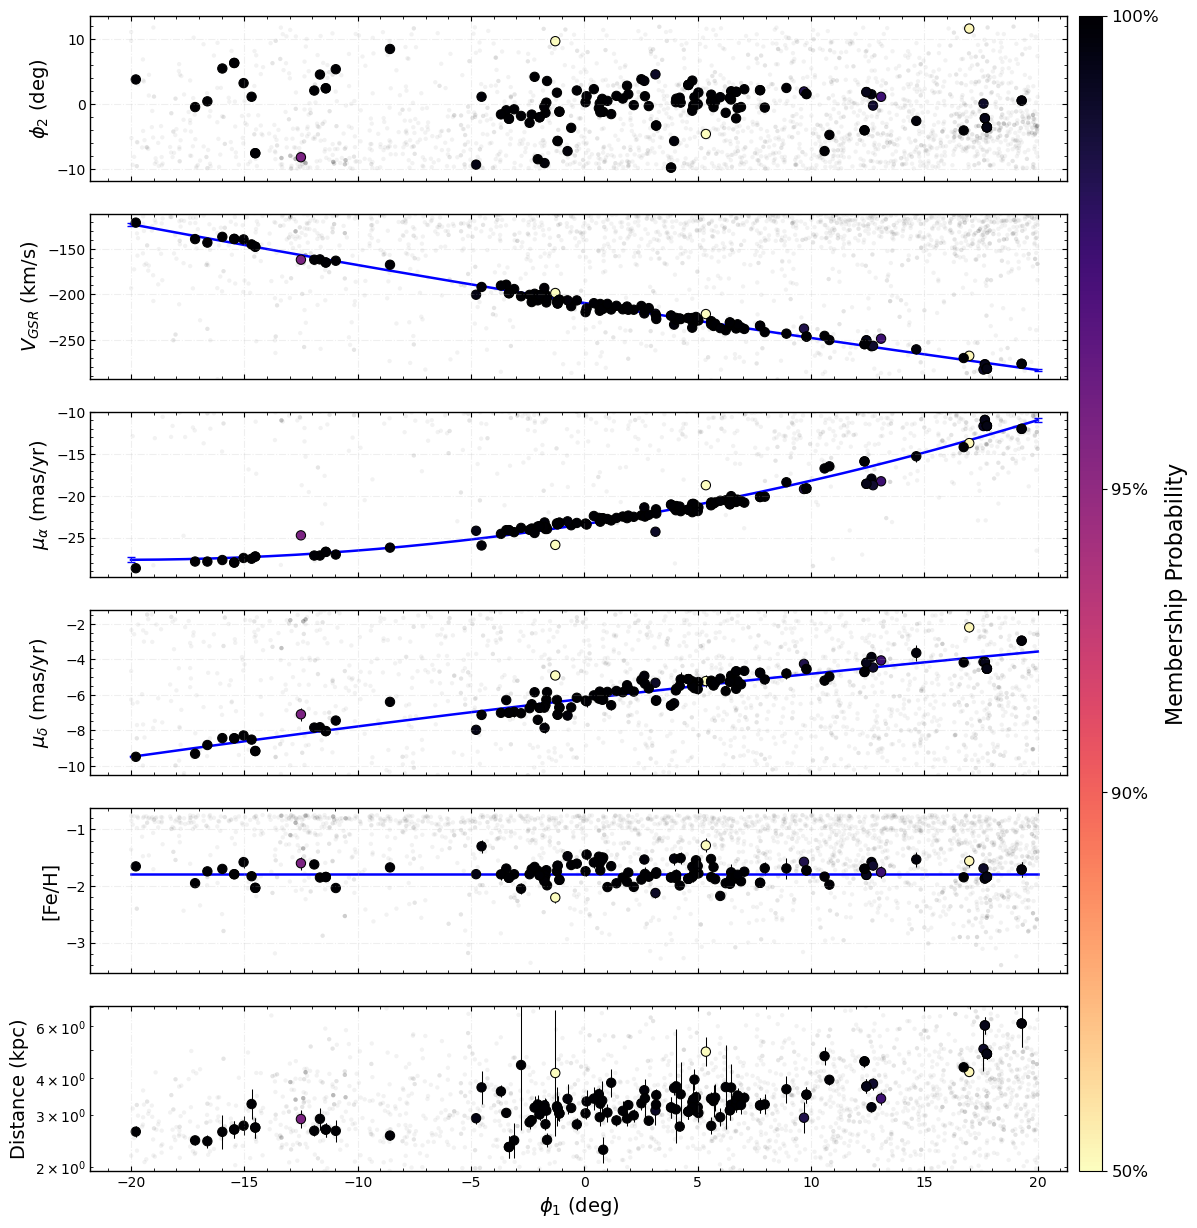

In [8]:
fig,ax = stream_.vis_6_panel(addBackground=True, save_fig=False, show_pm_dispersion=False,
                              show_vgsr_dispersion=False, dist_mod_panel=True, min_prob=0.5, residual=False, show_feh_dispersion=False)

In [9]:
stream_.print_meds()

param             med         em         ep   exp(med)    exp(em)    exp(ep)
--------------------------------------------------------------------------------------
pstream         0.052     -0.005      0.004
vgsr1        -122.186     -1.539      1.520
vgsr2        -209.427     -0.489      0.473
vgsr3        -283.655     -1.312      1.296
lsigvgsr        0.542     -0.042      0.047      3.481     -0.317      0.395
feh1           -1.791     -0.013      0.014
lsigfeh        -0.859     -0.032      0.034      0.138     -0.010      0.011
pmra1         -27.656     -0.291      0.297
pmra2         -23.395     -0.083      0.089
pmra3         -10.955     -0.247      0.252
lsigpmra       -0.135     -0.031      0.030      0.734     -0.050      0.053
pmdec1         -9.497     -0.189      0.185
pmdec2         -6.223     -0.055      0.055
pmdec3         -3.571     -0.155      0.165
lsigpmdec      -0.351     -0.034      0.034      0.446     -0.033      0.037
bv            196.545     -5.135      2.554


# Orbit Model

In [10]:
def flatter(obj):
    """
    Flattens mcmc output
    """
    for x in obj:
        if isinstance(x, (list, tuple)):
            yield from flatter(x)
        else:
            yield x
extended_meds = list(flatter(stream_.nested_dict['meds']))

In [11]:
for i, name in enumerate(stream_.nested_dict['expanded_param_labels']):
    print(i, name)
ex_dict = stream_.nested_dict['expanded_param_labels']

0 pstream
1 vgsr1
2 vgsr2
3 vgsr3
4 lsigvgsr
5 feh1
6 lsigfeh
7 pmra1
8 pmra2
9 pmra3
10 lsigpmra
11 pmdec1
12 pmdec2
13 pmdec3
14 lsigpmdec
15 bv
16 lsigbv
17 bfeh
18 lsigbfeh
19 bpmra
20 lsigbpmra
21 bpmdec
22 lsigbpmdec


orbit parameters ['dec', 'pmra', 'pmdec', 'vrad', 'dist', 'lsig_dec', 'lsig_pmra', 'lsig_pmdec', 'lsig_vrad']
intital guess [np.float64(4.175606648814856), np.float64(-21.872205697258313), np.float64(-6.321425291246975), np.float64(-225.24443868823045), np.float64(3.3826896640904844), np.float64(-1.0), np.float64(-1.0), np.float64(-1.0), np.float64(0.0)]
Optimization results_o:
Success: True
Status: 0
Message: Optimization terminated successfully.
Function Value: 1203.0041903123042
Number of Iterations: 4
Number of Function Evaluations: 373
Progenitor
dec: 7.16 deg
pmra: -22.07 mas / yr
pmdec: -5.85 mas / yr
vrad: -106.57 km / s
dist: 3.19 kpc
lsig_dec: 3.77 deg
lsig_pmra: 1.30 mas / yr or 19.64 km / s
lsig_pmdec: 0.52 mas / yr or 7.78 km / s
lsig_vrad: 12.71 km / s
Pericenter: 8.49 kpc 
Apocenter: 34.62 kpc
Orbital period: 0.59


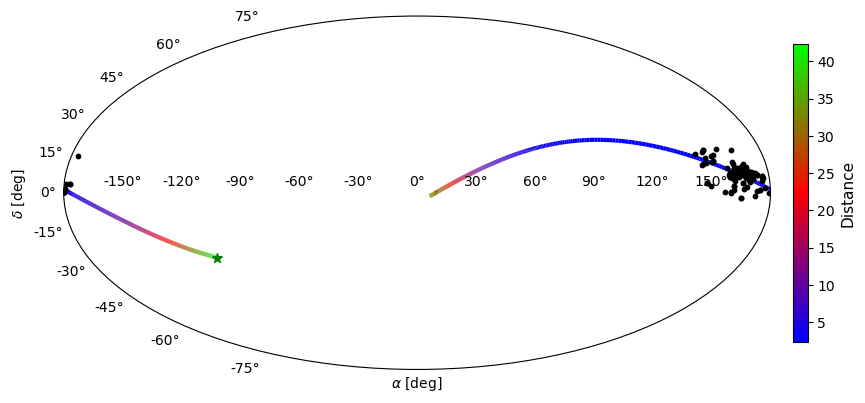

In [12]:
import orbit_functions as ofuncs
importlib.reload(ofuncs)

fw = np.linspace(0., 0.2, 1001) * u.Gyr
bw = np.linspace(0., -0.2, 1001) * u.Gyr

# progenitor_dist = 

stream_data['RA'] = np.array(stream_.stream_data['TARGET_RA'])
stream_data['DEC'] = np.array(stream_.stream_data['TARGET_DEC'])
stream_data['dist_kpc'] = 10**((stream_data['dist_mod']-10)/5)

progenitor_ra = np.nanmean(stream_data['RA'])
distances = np.abs(stream_data['RA'] - progenitor_ra)

k = np.argsort(distances)
avg_guess = {
    'DEC': np.nanmean(stream_data[k]['DEC'][:2]),
    'PMRA': np.nanmean(stream_data[k]['PMRA'][:2]),
    'PMDEC': np.nanmean(stream_data[k]['PMDEC'][:2]),
    'VRAD': np.nanmean(stream_data[k]['VGSR'][:2]),
    'DIST': np.nanmean(stream_data[k]['dist_kpc'][:2]),
}

lsig_dec_init = np.log10(0.1)  # Example: log10(0.1 deg)# lsig_dec_init = np.log10(0.1) # Example: log10(0.1 deg)
lsig_pmra_init = np.log10(0.1) # Example: log10(0.1 mas/yr)# lsig_pmra_init = np.log10(0.1) #extended_meds[ex_dict.index("lsigpmra")] # Example: log10(0.1 mas/yr)
lsig_pmdec_init = np.log10(0.1)# Example: log10(0.1 mas/yr)# lsig_pmdec_init = np.log10(0.1) #extended_meds[ex_dict.index("lsigpmdec")] # Example: log10(0.1 mas/yr)
lsig_vrad_init = np.log10(1.0) # Example: log10(1 km/s)# lsig_vrad_init = extended_meds[ex_dict.index("lsigvgsr")] # Example: log10(1 km/s)

theta_init = [
    avg_guess['DEC'],
    avg_guess['PMRA'],
    avg_guess['PMDEC'],
    avg_guess['VRAD'],
    avg_guess['DIST'],
    lsig_dec_init,
    lsig_pmra_init,
    lsig_pmdec_init,
    lsig_vrad_init
]

results_o, orbit, fig, ax = stream_.do_orbit(progenitor_RA=progenitor_ra,with_plot=True,theta_init=theta_init,fw=fw,bw=bw,use_mcmc=False)

/raid5b/users/nasserm/raid/nasserm/DESI_streamTutorial/libraries/post_mcmc.py:2476: UserWarning: Rasterization of 'Spine' will be ignored
  artist.set_rasterized(True)



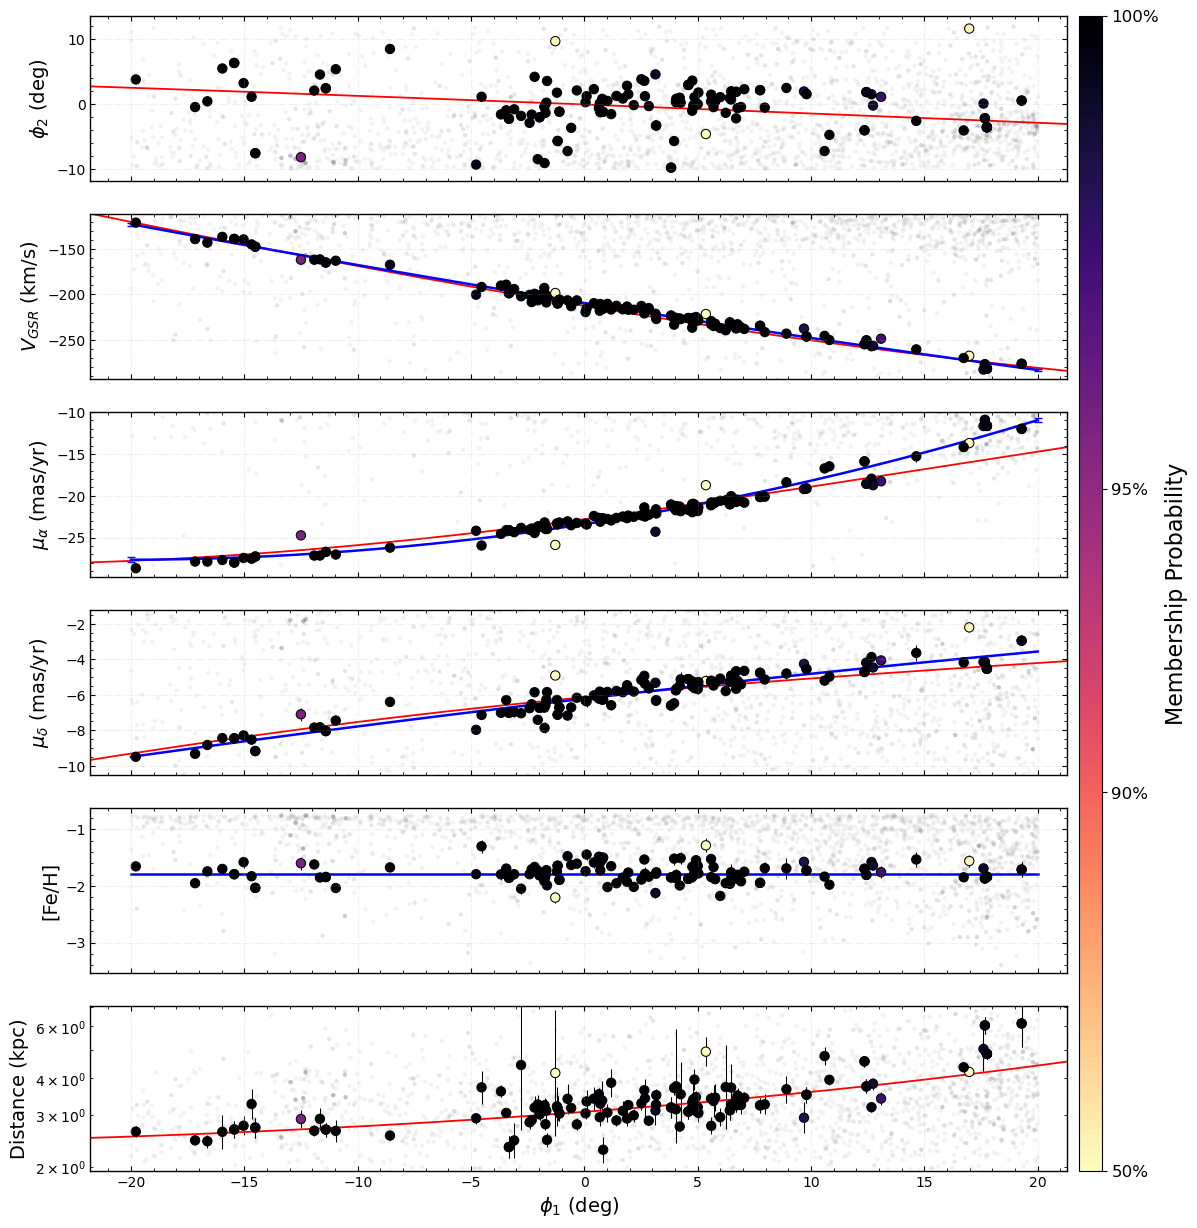

In [13]:
fig,ax = stream_.vis_6_panel(addBackground=True, save_fig=False, show_pm_dispersion=False,
                              show_vgsr_dispersion=False, dist_mod_panel=True, min_prob=0.5, residual=False, show_feh_dispersion=False)


In [17]:
np.linalg.norm(orbit.L())

np.float64(2990.0341213272227)